Análise Exploratória de Dados no Conjunto de Dados do Titanic
Este é o meu primeiro kernel e o objetivo deste kernel é conduzir uma análise exploratória de dados (EDA) e modelagem estatística no conjunto de dados do Titanic para obter insights e eventualmente prever sobreviventes (0 = Não Sobreviveu, 1 = Sobreviveu). Dos 891 passageiros que embarcaram no Titanic, aproximadamente 38% sobreviveram, enquanto a maioria, 62%, não sobreviveu ao desastre.

Abaixo, descrevo o processo que segui na condução do procedimento mencionado:

- Importar as bibliotecas Python relevantes para a análise.

- Carregar os conjuntos de dados de treino e teste e definir o índice, se aplicável.

- Inspecionar visualmente o cabeçalho do conjunto de dados, examinar o conjunto de dados de treino para entender,    em particular, se os dados estão organizados, verificar a forma do conjunto de dados, examinar tipos de dados, valores ausentes, contagens únicas e construir um dataframe de dicionário de dados.

- Executar estatísticas descritivas de tipos de dados de objetos e numéricos e, finalmente, transformar os tipos de dados conforme necessário.

- Realizar análises uni-variada, bi-variada e multivariada usando meios gráficos e não gráficos (alguns números representando os dados).

- Engenharia de Recursos: Extrair título do nome, extrair novos recursos de nome, idade, tarifa, sibsp, parch e cabine.

- Pré-processamento e preparação dos dados para modelagem estatística.

- Modelagem Estatística.

# Análise Exploratória de Dados (EDA) e modelagem estatística no conjunto de dados do Titanic.

## Passo 1: Importar Bibliotecas

Primeiro, vamos importar as bibliotecas necessárias e carregar os dados.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suprimindo FutureWarning
warnings.simplefilter(action='ignore', category=FutureWarning)


# Configurações para os gráficos
sns.set(style="whitegrid")
plt.style.use("fivethirtyeight")

## Passo 2: Carregar os Dados
Carregar os conjuntos de dados de treino e teste.

In [5]:
# Carregar os conjuntos de dados de treino e teste
train_df = pd.read_csv('https://github.com/Magno-Rodrigues/kaggle/blob/main/titanic_model/train.csv?raw=true')
test_df = pd.read_csv('https://github.com/Magno-Rodrigues/kaggle/blob/main/titanic_model/test.csv?raw=true')

# Visualizar os primeiros registros do conjunto de dados de treino
display(train_df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Passo 3: Inspecionar os Dados
Inspecionar visualmente o cabeçalho do conjunto de dados, verificar a forma, os tipos de dados e os valores ausentes.

In [6]:
# Inspecionar o cabeçalho do conjunto de dados
display(train_df.info())

# Verificar a forma do conjunto de dados
display(train_df.shape)

# Verificar valores ausentes
display(train_df.isnull().sum())

# Estatísticas descritivas
display(train_df.describe(include='all'))

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


None

(891, 12)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


## Passo 4: Estatísticas Descritivas
Executar estatísticas descritivas de tipos de dados de objetos e numéricos e transformar os tipos de dados conforme necessário.

In [7]:
# Estatísticas descritivas para variáveis numéricas
display(train_df.describe())

# Estatísticas descritivas para variáveis categóricas
display(train_df.describe(include=['object', 'string']))

# Transformar tipos de dados, se necessário
# Exemplo: train_df['Survived'] = train_df['Survived'].astype('category')

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


## Passo 5: Análise Univariada
Vamos analisar cada variável independentemente para entender suas distribuições.

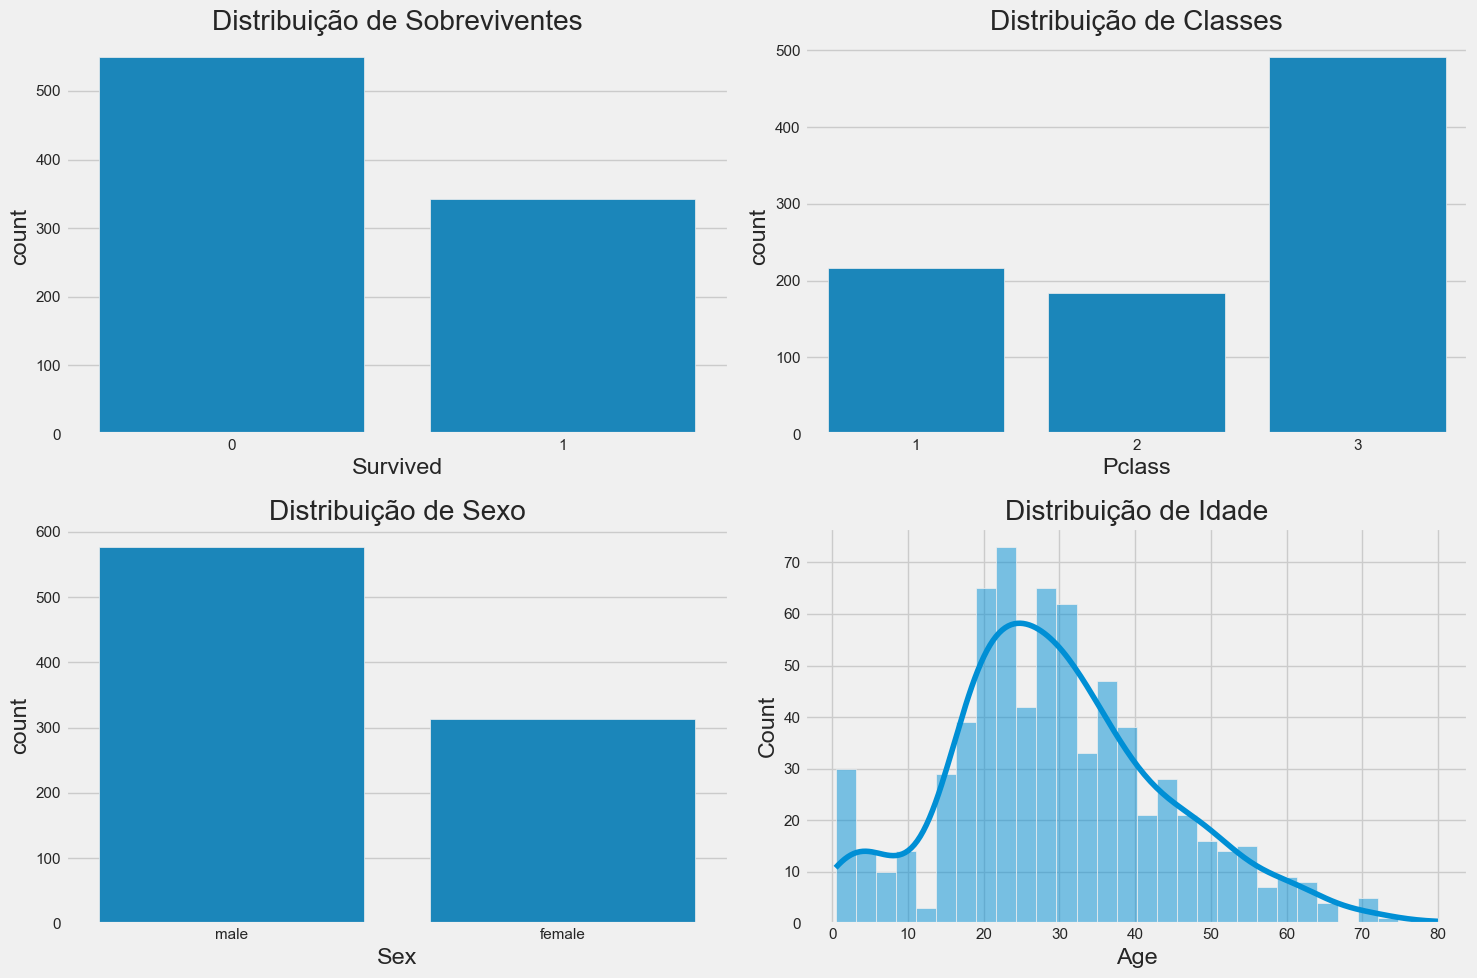

In [8]:
# Configurar a figura para múltiplos gráficos
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Distribuição de sobreviventes
sns.countplot(ax=axes[0, 0], x='Survived', data=train_df)
axes[0, 0].set_title('Distribuição de Sobreviventes')

# Distribuição de classes
sns.countplot(ax=axes[0, 1], x='Pclass', data=train_df)
axes[0, 1].set_title('Distribuição de Classes')

# Distribuição de sexo
sns.countplot(ax=axes[1, 0], x='Sex', data=train_df)
axes[1, 0].set_title('Distribuição de Sexo')

# Distribuição de idades
sns.histplot(ax=axes[1, 1], data=train_df['Age'].dropna(), kde=True, bins=30)
axes[1, 1].set_title('Distribuição de Idade')

plt.tight_layout()
plt.show()

## Passo 6: Análise Bivariada
Analisar como as variáveis independentes estão relacionadas com a variável dependente 'Survived'.

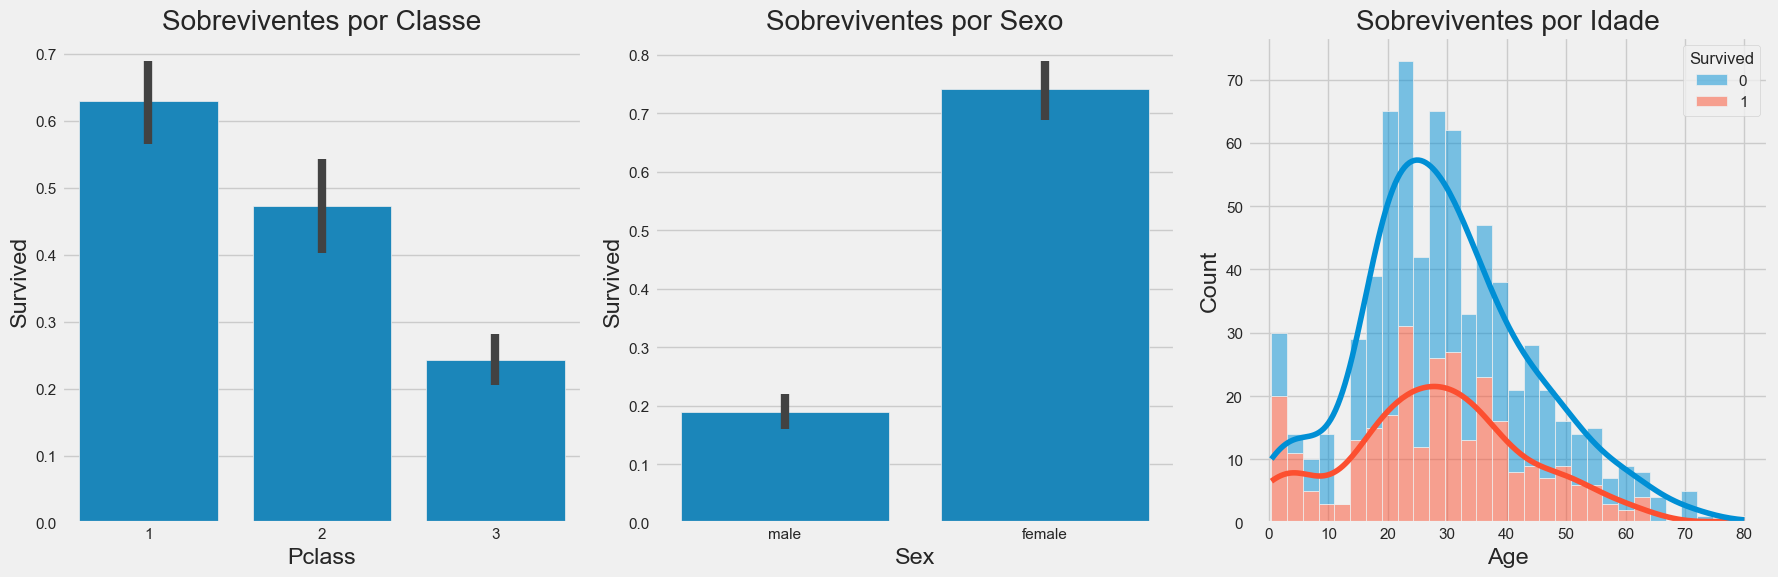

In [9]:
# Configurar a figura para múltiplos gráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Sobreviventes por classe
sns.barplot(ax=axes[0], x='Pclass', y='Survived', data=train_df)
axes[0].set_title('Sobreviventes por Classe')

# Sobreviventes por sexo
sns.barplot(ax=axes[1], x='Sex', y='Survived', data=train_df)
axes[1].set_title('Sobreviventes por Sexo')

# Sobreviventes por idade
sns.histplot(ax=axes[2], data=train_df, x='Age', hue='Survived', multiple='stack', kde=True, bins=30)
axes[2].set_title('Sobreviventes por Idade')

plt.tight_layout()
plt.show()

## Passo 7: Engenharia de Recursos
Vamos criar novos recursos a partir dos dados existentes.

In [10]:
# Extrair título do nome
train_df['Title'] = train_df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
test_df['Title'] = test_df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# Verificar a distribuição de títulos
display(train_df['Title'].value_counts())

# Mapear títulos raros para 'Rare'
rare_titles = train_df['Title'].value_counts()[train_df['Title'].value_counts() < 10].index
train_df['Title'] = train_df['Title'].replace(rare_titles, 'Rare')
test_df['Title'] = test_df['Title'].replace(rare_titles, 'Rare')

# Mapear os títulos para números
title_mapping = {'Mr': 1, 'Miss': 2, 'Mrs': 3, 'Master': 4, 'Rare': 5}
train_df['Title'] = train_df['Title'].map(title_mapping)
test_df['Title'] = test_df['Title'].map(title_mapping)

# Verificar o dataframe atualizado
display(train_df.head())

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,3
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,3
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1


## Passo 8: Pré-processamento e Preparação dos Dados
Vamos lidar com valores ausentes e preparar os dados para a modelagem.

In [11]:
# Preenchendo valores ausentes
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())
test_df['Age'] = test_df['Age'].fillna(test_df['Age'].median())

train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])
test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].median())

# Verificar novamente valores ausentes
display(train_df.isnull().sum())
display(test_df.isnull().sum())

# Convertendo variáveis categóricas em dummy/indicadores
train_df = pd.get_dummies(
    train_df,
    columns=['Sex', 'Embarked', 'Title'],
    drop_first=True
)

test_df = pd.get_dummies(
    test_df,
    columns=['Sex', 'Embarked', 'Title'],
    drop_first=True
)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
Title            0
dtype: int64

PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
Title            1
dtype: int64

## Passo 9: Modelagem Estatística
Vamos criar um modelo de aprendizado de máquina para prever a sobrevivência.

Acurácia do Modelo: 0.8101


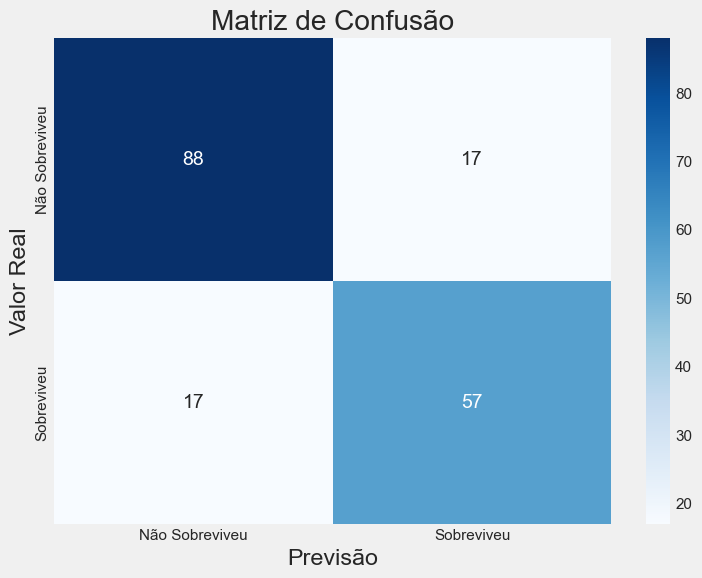

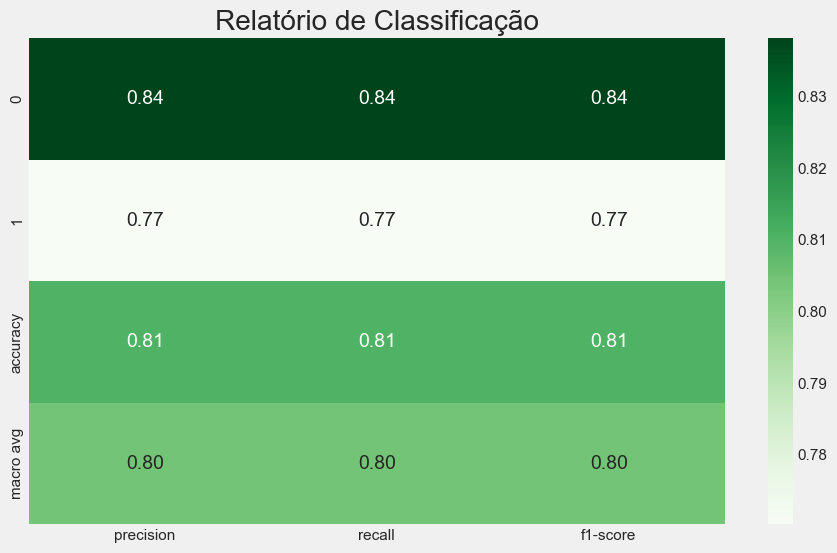

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Copiando dataframe já tratado
df = train_df.copy()

# Features
X = df.drop(
    ['Survived', 'Name', 'Ticket', 'Cabin', 'PassengerId'],
    axis=1,
    errors='ignore'
)

# Target
y = df['Survived']

# Divisão treino/validação
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Modelo
model = LogisticRegression(max_iter=1000)

# Treinamento
model.fit(X_train, y_train)

# Previsões
y_pred = model.predict(X_val)

# Acurácia
accuracy = accuracy_score(y_val, y_pred)

print(f'Acurácia do Modelo: {accuracy:.4f}')

# =========================
# MATRIZ DE CONFUSÃO
# =========================

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Não Sobreviveu', 'Sobreviveu'],
    yticklabels=['Não Sobreviveu', 'Sobreviveu']
)

plt.title('Matriz de Confusão')
plt.xlabel('Previsão')
plt.ylabel('Valor Real')

plt.show()

# =========================
# RELATÓRIO DE CLASSIFICAÇÃO
# =========================

report = classification_report(
    y_val,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

plt.figure(figsize=(10, 6))

sns.heatmap(
    report_df.iloc[:-1, :-1],
    annot=True,
    cmap='Greens',
    fmt='.2f'
)

plt.title('Relatório de Classificação')
plt.show()